Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Afficionado Coffee Roasters.xlsx - Transactions.csv to Afficionado Coffee Roasters.xlsx - Transactions.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Afficionado Coffee Roasters.xlsx - Transactions.csv")
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


Basic Data Understanding

In [ ]:
print("Shape:", df.shape)

Shape: (149116, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 12.5+ MB


In [ ]:
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [ ]:
df.isnull().sum()

,0
transaction_id,0
year,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Revenue Column

In [ ]:
df["Revenue"] = df["transaction_qty"] * df["unit_price"]

In [ ]:
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


Main KPIs

In [ ]:
total_revenue = df["Revenue"].sum()
total_transactions = df["transaction_id"].nunique()
total_qty = df["transaction_qty"].sum()
total_products = df["product_detail"].nunique()

print("Total Revenue:", total_revenue)
print("Total Transactions:", total_transactions)
print("Total Quantity:", total_qty)
print("Total Products:", total_products)

Total Revenue: 698812.3300000002
Total Transactions: 149116
Total Quantity: 214470
Total Products: 80


Top Selling Products

In [ ]:
top_sales = (
    df.groupby("product_detail")["transaction_qty"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_sales

,transaction_qty
product_detail,
Earl Grey Rg,4708
Dark chocolate Lg,4668
Morning Sunrise Chai Rg,4643
Latte,4602
Peppermint Rg,4564
Columbian Medium Roast Rg,4547
Traditional Blend Chai Rg,4512
Latte Rg,4497
Our Old Time Diner Blend Sm,4484


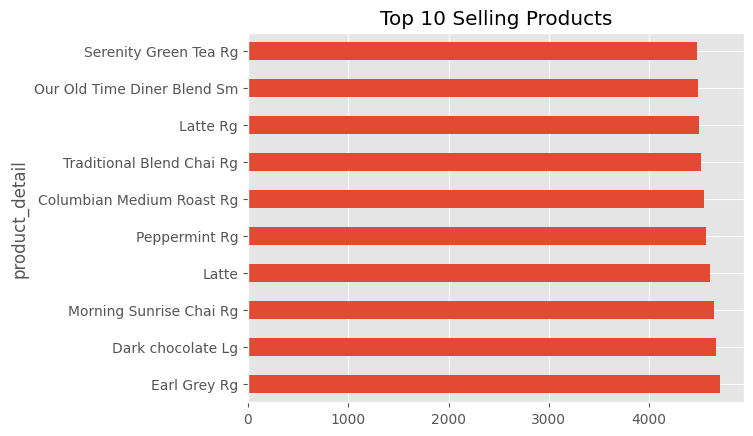

In [ ]:
top_sales.plot(kind="barh")
plt.title("Top 10 Selling Products")
plt.show()

Top Revenue Products

In [ ]:
top_revenue = (
    df.groupby("product_detail")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue

,Revenue
product_detail,
Sustainably Grown Organic Lg,21151.75
Dark chocolate Lg,21006.00
Latte Rg,19112.25
Cappuccino Lg,17641.75
Morning Sunrise Chai Lg,17384.00
Latte,17257.50
Jamaican Coffee River Lg,16481.25
Sustainably Grown Organic Rg,16233.75
Cappuccino,15997.50


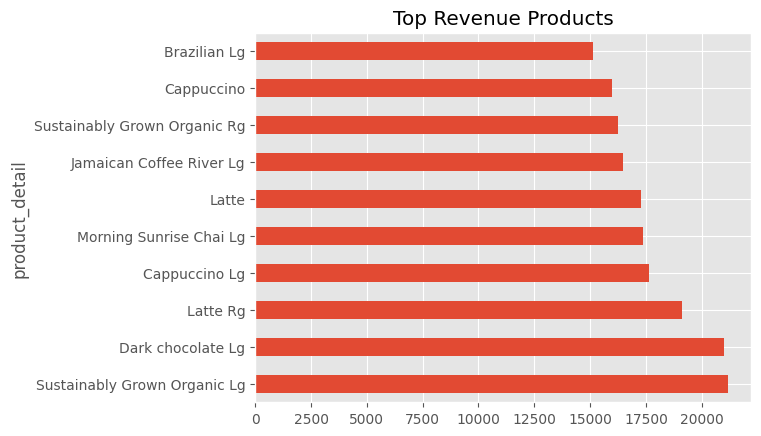

In [ ]:
top_revenue.plot(kind="barh")
plt.title("Top Revenue Products")
plt.show()

## Category Revenue Analysis

Revenue by Category

In [ ]:
category_revenue = (
    df.groupby("product_category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

,Revenue
product_category,
Coffee,269952.45
Tea,196405.95
Bakery,82315.64
Drinking Chocolate,72416.00
Coffee beans,40085.25
Branded,13607.00
Loose Tea,11213.60
Flavours,8408.80
Packaged Chocolate,4407.64


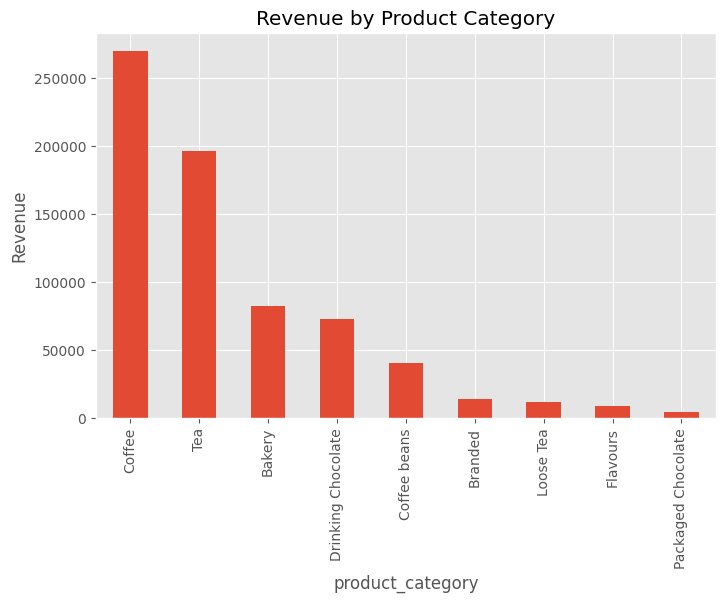

In [ ]:
plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.ylabel("Revenue")
plt.show()

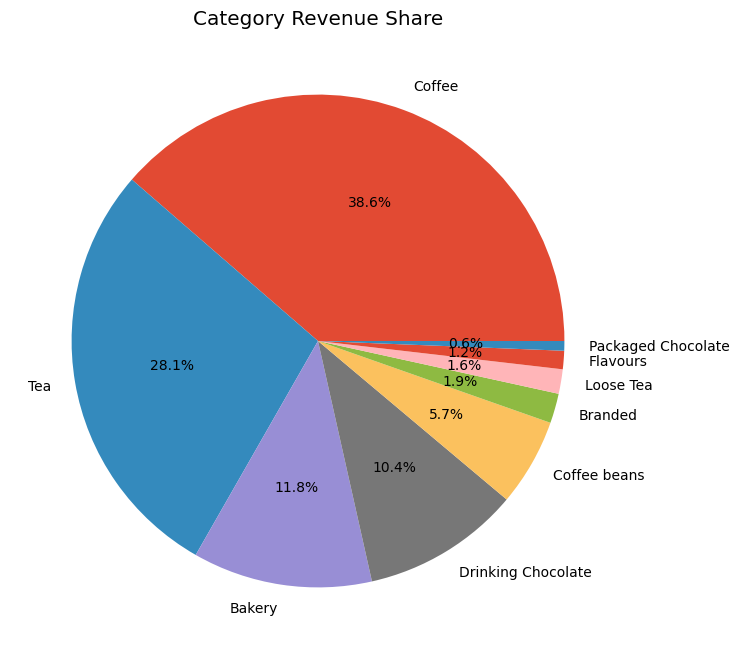

In [ ]:
# pie chart
plt.figure(figsize=(8,8))
category_revenue.plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Category Revenue Share")
plt.show()

## Store Performance Analysis


Revenue by Store

In [ ]:
store_revenue = (
    df.groupby("store_location")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

store_revenue

,Revenue
store_location,
Hell's Kitchen,236511.17
Astoria,232243.91
Lower Manhattan,230057.25


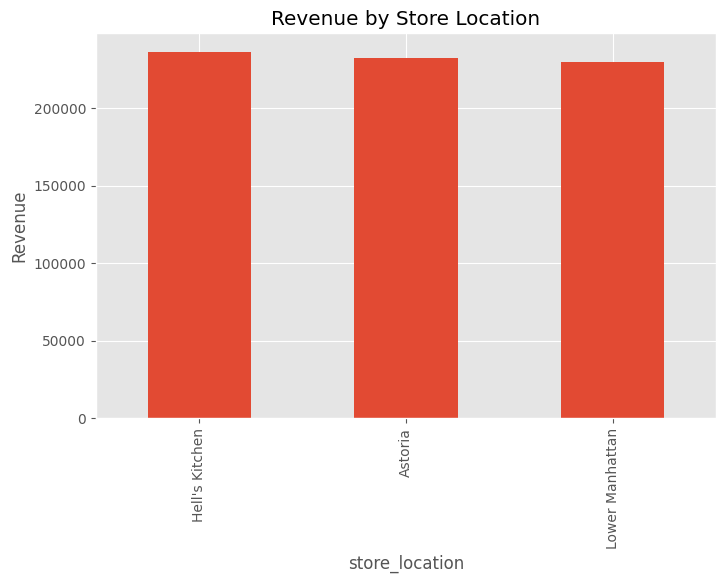

In [ ]:
plt.figure(figsize=(8,5))
store_revenue.plot(kind="bar")
plt.title("Revenue by Store Location")
plt.ylabel("Revenue")
plt.show()

Product Type Analysis

In [ ]:
product_type_revenue = (
    df.groupby("product_type")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

product_type_revenue

,Revenue
product_type,
Barista Espresso,91406.20
Brewed Chai tea,77081.95
Hot chocolate,72416.00
Gourmet brewed coffee,70034.60
Brewed Black tea,47932.00
Brewed herbal tea,47539.50
Premium brewed coffee,38781.15
Organic brewed coffee,37746.50
Scone,36866.12


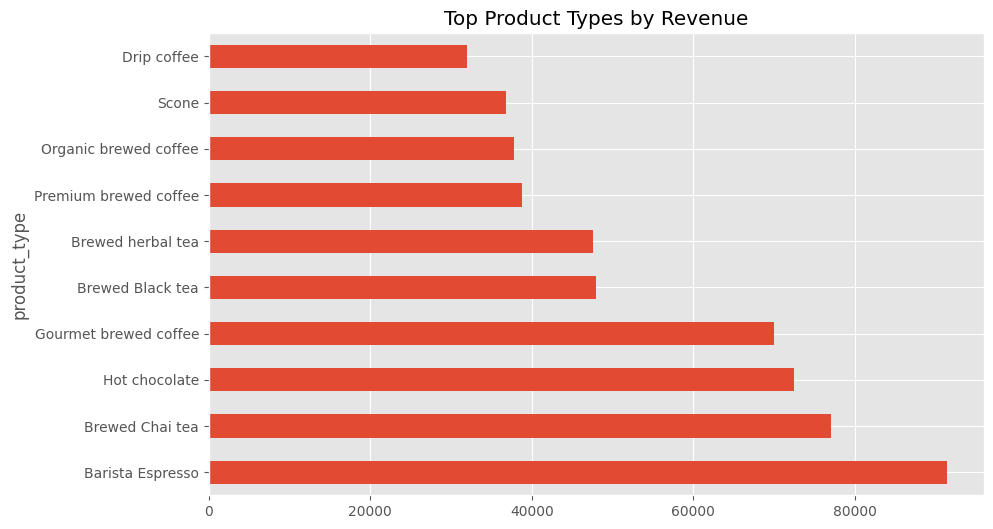

In [ ]:
plt.figure(figsize=(10,6))
product_type_revenue.plot(kind="barh")
plt.title("Top Product Types by Revenue")
plt.show()

## Popularity vs Revenue

In [ ]:
product_summary = df.groupby("product_detail").agg({
    "transaction_qty":"sum",
    "Revenue":"sum"
}).reset_index()

product_summary.head()

,product_detail,transaction_qty,Revenue
0,Almond Croissant,1911,7168.13
1,Brazilian - Organic,214,3852.00
2,Brazilian Lg,4317,15109.50
3,Brazilian Rg,4385,13155.00
4,Brazilian Sm,4310,9482.00


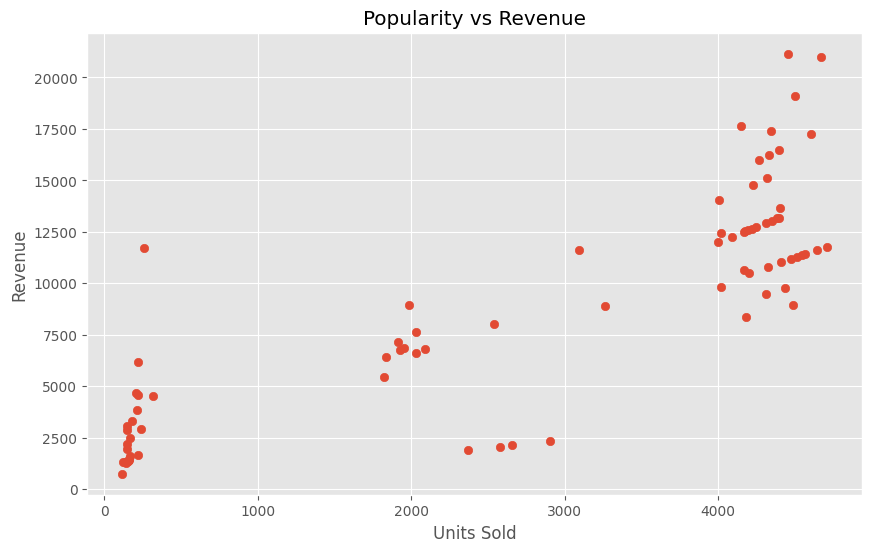

In [ ]:
# Scatter Plot
plt.figure(figsize=(10,6))

plt.scatter(
    product_summary["transaction_qty"],
    product_summary["Revenue"]
)

plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.title("Popularity vs Revenue")
plt.show()

Business Insight

Products in the upper-right quadrant are hero products that combine strong demand with strong revenue generation.

Products in the lower-left quadrant may require review
or removal from the menu.

Pareto (80/20) Analysis

In [ ]:
pareto = (
    df.groupby("product_detail")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

pareto.head()

,product_detail,Revenue
0,Sustainably Grown Organic Lg,21151.75
1,Dark chocolate Lg,21006.00
2,Latte Rg,19112.25
3,Cappuccino Lg,17641.75
4,Morning Sunrise Chai Lg,17384.00


In [ ]:
pareto["Revenue_%"] = (
    pareto["Revenue"] /
    pareto["Revenue"].sum()
) * 100

In [ ]:
pareto["Cumulative_%"] = (
    pareto["Revenue_%"]
    .cumsum()
)

In [ ]:
pareto.head(20)


,product_detail,Revenue,Revenue_%,Cumulative_%
0,Sustainably Grown Organic Lg,21151.75,3.026814,3.026814
1,Dark chocolate Lg,21006.00,3.005957,6.032771
2,Latte Rg,19112.25,2.734962,8.767733
3,Cappuccino Lg,17641.75,2.524533,11.292266
4,Morning Sunrise Chai Lg,17384.00,2.487649,13.779916
5,Latte,17257.50,2.469547,16.249463
6,Jamaican Coffee River Lg,16481.25,2.358466,18.607929
7,Sustainably Grown Organic Rg,16233.75,2.323049,20.930977
8,Cappuccino,15997.50,2.289241,23.220219
9,Brazilian Lg,15109.50,2.162168,25.382387


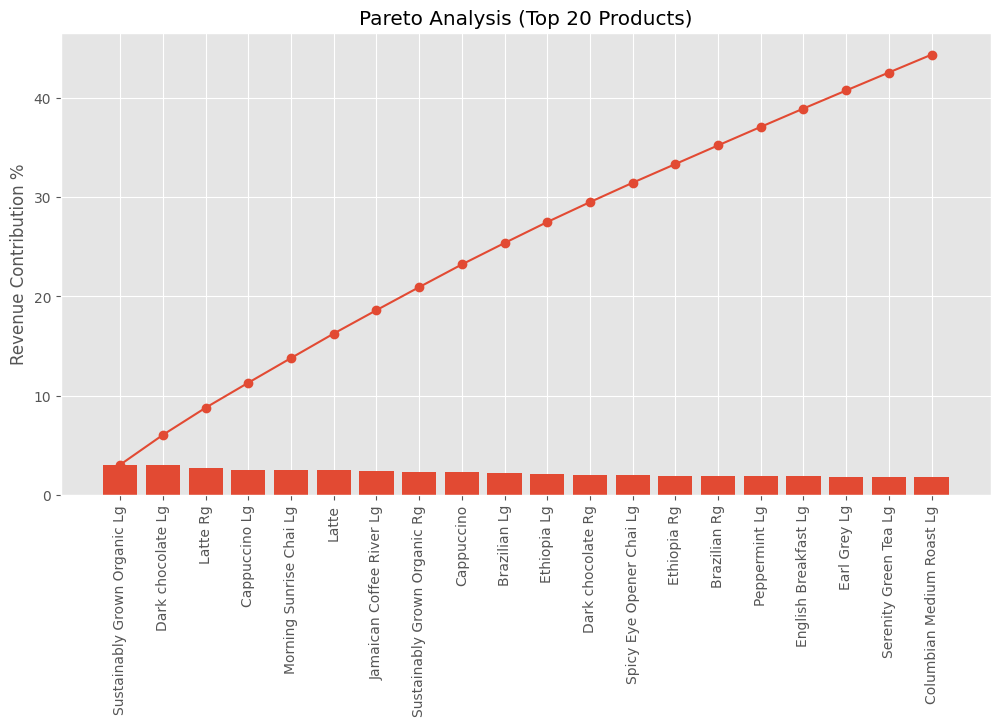

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(
    pareto["product_detail"][:20],
    pareto["Revenue_%"][:20]
)

plt.plot(
    pareto["product_detail"][:20],
    pareto["Cumulative_%"][:20],
    marker="o"
)

plt.xticks(rotation=90)

plt.title("Pareto Analysis (Top 20 Products)")
plt.ylabel("Revenue Contribution %")

plt.show()

In [ ]:
top_80 = pareto[pareto["Cumulative_%"] <= 80]

print("Products generating ~80% revenue:")
print(len(top_80))

Products generating ~80% revenue:
42


In [ ]:
top_80[["product_detail","Revenue","Cumulative_%"]]

,product_detail,Revenue,Cumulative_%
0,Sustainably Grown Organic Lg,21151.75,3.026814
1,Dark chocolate Lg,21006.00,6.032771
2,Latte Rg,19112.25,8.767733
3,Cappuccino Lg,17641.75,11.292266
4,Morning Sunrise Chai Lg,17384.00,13.779916
5,Latte,17257.50,16.249463
6,Jamaican Coffee River Lg,16481.25,18.607929
7,Sustainably Grown Organic Rg,16233.75,20.930977
8,Cappuccino,15997.50,23.220219
9,Brazilian Lg,15109.50,25.382387


Revenue Concentration Ratio KPI

In [ ]:
top10_revenue = pareto.head(10)["Revenue"].sum()

revenue_concentration_ratio = (
    top10_revenue /
    pareto["Revenue"].sum()
) * 100

print(
    f"Top 10 products contribute {revenue_concentration_ratio:.2f}% of total revenue"
)

Top 10 products contribute 25.38% of total revenue


Product Efficiency Score KPI

In [ ]:
efficiency = df.groupby("product_detail").agg({
    "Revenue":"sum",
    "transaction_qty":"sum"
})

efficiency["Efficiency_Score"] = (
    efficiency["Revenue"] /
    efficiency["transaction_qty"]
)

efficiency.sort_values(
    by="Efficiency_Score",
    ascending=False
).head(10)

,Revenue,transaction_qty,Efficiency_Score
product_detail,,,
Civet Cat,11700.00,260,45.000000
I Need My Bean! T-shirt,6163.00,221,27.886878
Organic Decaf Blend,4657.50,206,22.609223
Ethiopia,4578.00,218,21.000000
Primo Espresso Roast,3067.50,150,20.450000
Jamacian Coffee River,2883.50,146,19.750000
Our Old Time Diner Blend,3294.00,183,18.000000
Brazilian - Organic,3852.00,214,18.000000
Columbian Medium Roast,2220.00,148,15.000000
